In [1]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np
import geopandas as gpd

# For st autocorrelation
import libpysal as lps
from scipy.spatial.distance import cdist
from shapely.geometry import Point
import libpysal.weights as weights
from libpysal.weights import DistanceBand, KNN
from pysal.explore import esda
from splot.esda import plot_moran
from esda.moran import Moran, Moran_Local


# For plotting
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn
import matplotlib as mpl

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')

nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [3]:
sdate, edate = '2009-07-01','2024-06-30'

In [4]:
gen_details = pd.read_csv(f"{nmap_path}/gen_details.csv",index_col=False)

In [5]:
nmap = pd.read_csv(f"{nmap_path}/nmap.csv",index_col=False)

In [6]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv",index_col=False)

In [7]:
def process_group(grp, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Processes a single group of generator data.

    Parameters:
        grp (pd.DataFrame): A single group from gen_details (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """
    gen_locs = gen_fpath + '/' + grp['DUID'] + ".csv"
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]

    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        dfs.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )

    return merged

In [8]:
def process_all(gen_details, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Process all generator data in gen_details without grouping. Ignores loads and batteries.
    
    Parameters:
        gen_details (pd.DataFrame): DataFrame containing at least 'duid' column.
        gen_fpath (str): Directory path containing CSV files named by DUID.
        hw_tseries (pd.DataFrame): Heatwave timeseries data with 'time' and 'DUID'.
        start_date (str): Start date for filtering time series.
        end_date (str): End date for filtering time series.
    
    Returns:
        pd.DataFrame: Merged dataframe with summed TOTALMWh per DUID per hour and heatwave info.
    """
    # Build file paths for all DUIDs,ignoring batteries
    non_batt = gen_details[gen_details['fuel_source_primary'] != 'Battery']
    non_batt = non_batt[non_batt['fuel_source_primary'] != '-']
    non_batt = non_batt[non_batt['dispatch_type'] == 'Generator']['DUID']
    gen_locs = gen_fpath + '/' + non_batt + ".csv"

    # Read all existing CSVs
    dfs = [pd.read_csv(fp) for fp in gen_locs if os.path.exists(fp)]
    
    if not dfs:
        print("[WARN] No data files found for any DUID.")
        return pd.DataFrame()  # Return empty if no files
    
    # Concatenate all data
    dfs = pd.concat(dfs, ignore_index=True)

    # Convert time to datetime and filter
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'min'}
    grouped = dfs.groupby(['DUID', pd.Grouper(freq='1h')]).agg(agg_func).reset_index()

    # Sort hw_tseries once
    hw_sorted = hw_tseries.sort_values(by=['time', 'DUID'])

    # Merge with heatwave timeseries
    merged = pd.merge_asof(
        grouped.sort_values(by=['time', 'DUID']),
        hw_sorted,
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )
    
    return merged

In [9]:
def clean_df(df,t1,t2,hw=False,gen_details=gen_details,AGC=False):
    df = df.merge(gen_details[['DUID', 'reg_cap_generation_mw']], on='DUID', how='left')
    df['reg_cap_generation_mw'] = df['reg_cap_generation_mw'].astype('float')
    df['cap_norm'] = df['TOTALMWh']/df['reg_cap_generation_mw']
    df = df[~((df['cap_norm'] > 2) | (df['cap_norm'] <0)) ]
    df = df.drop('reg_cap_generation_mw',axis=1)

    df_sliced = df.loc[(df['time'].dt.month >= 11)| (df['time'].dt.month <= 3)].set_index('time')
    df_sliced = df_sliced.between_time(t1,t2).reset_index()

    if hw == True:
        df_sliced = df_sliced[df_sliced['EHF_flag'] == 1]

    if AGC == True:
        df_sliced = df_sliced[df_sliced['AGCSTATUS'] == 1]
    
    return df_sliced

In [10]:
def build_gdf(df,nmap,var,method,thresh):
    # have to slice nmap for relevant DUIDS
    nmap = nmap[nmap.DUID.isin(df['DUID'])]
    geometry = [Point(xy) for xy in zip(nmap['lon'], nmap['lat'])]
    gdf = gpd.GeoDataFrame(nmap, geometry=geometry)
    
    # Set coordinate reference system (EPSG 4283 = GDA94)
    gdf = gdf.set_crs(epsg=4283, inplace=True).to_crs(epsg=3857)
    gdf = gdf.dropna(subset=['lat','lon'])
    
    agg_func = {var:method}
    agg_df = df.groupby(['DUID']).aggregate(agg_func).reset_index()
    gdf = pd.merge(gdf, agg_df, on='DUID').dropna()

    # Build weights matrix using distanceband (continous) and kNN for outliers
    w = weights.DistanceBand.from_dataframe(gdf,threshold=thresh,binary=False)
    
    # Check for islands
    islands = w.islands
    
    # Assign manual neighbours
    if islands:
        w_knn = KNN.from_dataframe(gdf, k=1)
    
        for island in islands:
            # Get the index of the nearest neighbor
            nearest = w_knn.neighbors[island][0]
    
            # Assign that neighbor in the DistanceBand weights
            w.neighbors[island] = [nearest]
            w.weights[island] = [1.0]
    
            # Optional: make it reciprocal (symmetrical)
            if island not in w.neighbors[nearest]:
                w.neighbors[nearest].append(island)
                w.weights[nearest].append(1.0)
    
    # Row-standardize
    w.transform = 'R'

    return gdf,w

In [11]:
ft_groups = gen_details.groupby(['fuel_source_primary'])
grp = ft_groups.get_group(('Wind',))
# grouped_A = grp[grp['region'] == 'NSW1']
# grouped_B = grp[grp['region'] == 'VIC1']

# grp = pd.concat([grouped_A, grouped_B])

df = process_group(grp, gen_fpath, hw_tseries)

# Running for solar, taking a snapshot at 2PM for solar noon, AGC does not apply
df = clean_df(df,'10:00','14:00')

In [12]:
var = 'cap_norm'
gdf, w = build_gdf(df,nmap, var,'mean',300000);

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/libpysal/weights/util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 4 islands with ids: 34, 40, 44, 61.
  w = W(neighbors, weights, ids, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/libpysal/weights/distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 4 islands with ids: 34, 40, 44, 61.
  W.__init__(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 17 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


(array([7., 3., 0., 0., 0., 1., 3., 0., 6., 3., 0., 0., 0., 5., 2., 6., 3.,
        9., 0., 7., 1., 5., 4., 1.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]),
 <BarContainer object of 24 artists>)

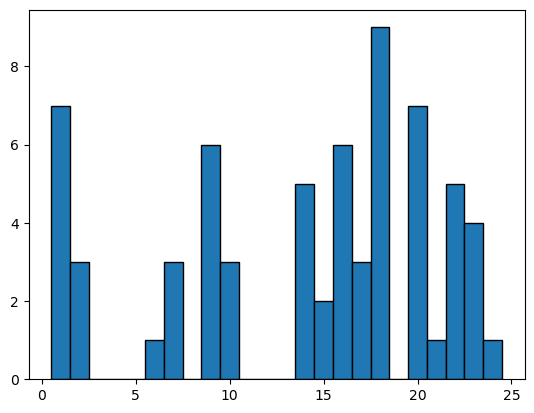

In [13]:
# Remember to check number of neighbours and adjust threshold accordingly

cardinalities = list(w.cardinalities.values())
cardinalitites = [int(i) for i in cardinalities]
plt.hist(cardinalities, bins=range(min(cardinalities), max(cardinalities) + 2), edgecolor='black', align='left')

In [14]:
moran = esda.moran.Moran(gdf['cap_norm'], w)

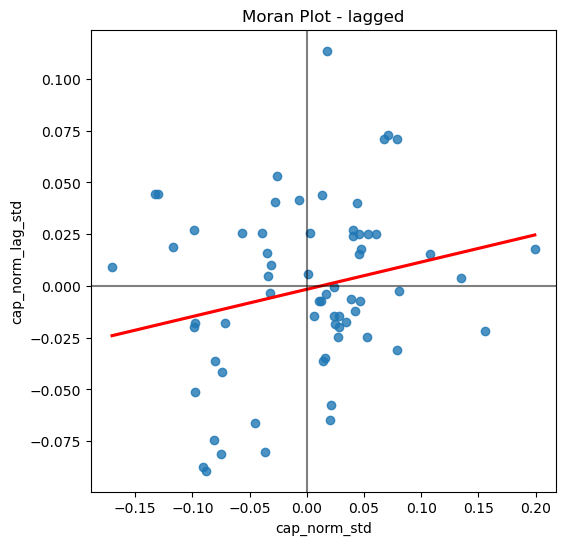

In [15]:
gdf[f"{var}_std"] = gdf[var] - gdf[var].mean()
gdf[f"{var}_lag_std"] = weights.lag_spatial(
    w, gdf[f"{var}_std"]
)

f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x=f"{var}_std",
    y=f"{var}_lag_std",
    ci=None,
    data=gdf,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - lagged")
plt.show()

Moran's I: 0.131698714006358, p-value: 0.065


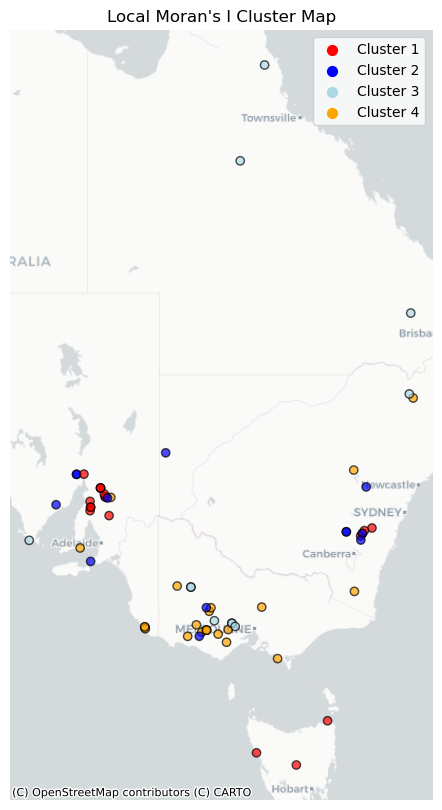

In [16]:
# Cluster map
y = gdf[f'{var}_std'].values

# Calculate Global Moran's I
mi = Moran(y, w)
print(f"Moran's I: {mi.I}, p-value: {mi.p_sim}")

# Calculate Local Moran's I
m_local = Moran_Local(y, w)

# Assign cluster types (1=HH, 2=LH, 3=LL, 4=HL)
gdf['cluster'] = m_local.q

# Map cluster values to colors
colors = {
    1: 'red',       # High-High
    2: 'blue',      # Low-High
    3: 'lightblue', # Low-Low
    4: 'orange'     # High-Low
}
gdf['color'] = gdf['cluster'].map(colors)

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color=gdf['color'], alpha=0.7, edgecolor='k')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=5)

# Optional legend
for cluster_id, color in colors.items():
    ax.scatter([], [], c=color, label=f'Cluster {cluster_id}', s=50)
ax.legend()

plt.title("Local Moran's I Cluster Map")
plt.axis('off')
plt.show()

Moran's I: 0.131698714006358, p-value: 0.07


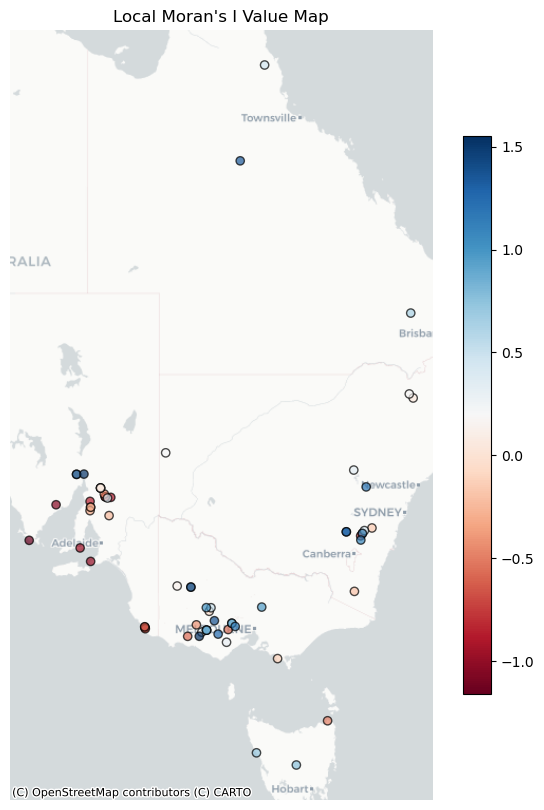

In [17]:
#  I value map
gdf = gdf.to_crs(epsg=3857)
y = gdf[f'{var}_std'].values

# Calculate Global Moran's I
mi = Moran(y, w)
print(f"Moran's I: {mi.I}, p-value: {mi.p_sim}")

# Calculate Local Moran's I
m_local = Moran_Local(y, w)

gdf['I'] = m_local.Is

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, c=gdf['I'], cmap='RdBu', alpha=0.7, edgecolor='k')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=5)

cmap = mpl.colormaps['RdBu']
norm = mpl.colors.Normalize(vmin=gdf['I'].min(), vmax=gdf['I'].max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # Dummy array for the ScalarMappable

cbar = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
# cbar.set_label('Local Moran's I Value')

plt.title("Local Moran's I Value Map")
plt.axis('off')
plt.show()

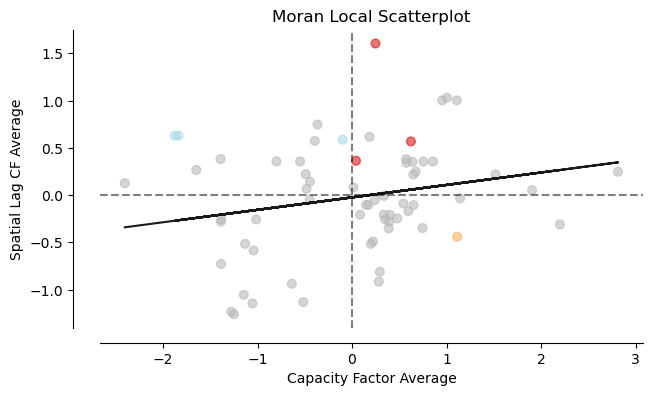

In [18]:
from splot.esda import plot_moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(m_local, p=0.05)
ax.set_xlabel('Capacity Factor Average')
ax.set_ylabel('Spatial Lag CF Average')
plt.show()

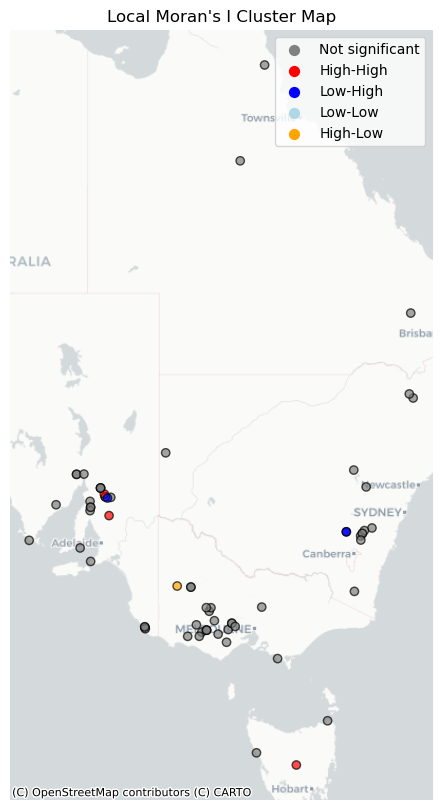

In [19]:
# Significance level
alpha = 0.05

# Create a mask for significant observations
significant = m_local.p_sim < alpha

# Assign cluster types only for significant locations
gdf['cluster'] = np.where(significant, m_local.q, 0)  # 0 = not significant

# Define color mapping, include 0 → 'grey'
colors = {
    0: 'grey',      # Not significant
    1: 'red',       # High-High
    2: 'blue',      # Low-High
    3: 'lightblue', # Low-Low
    4: 'orange'     # High-Low
}
gdf['color'] = gdf['cluster'].map(colors)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color=gdf['color'], alpha=0.7, edgecolor='k')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=5)

# Create legend including 'Not significant'
legend_labels = {
    0: 'Not significant',
    1: 'High-High',
    2: 'Low-High',
    3: 'Low-Low',
    4: 'High-Low'
}
for cluster_id, color in colors.items():
    ax.scatter([], [], c=color, label=legend_labels[cluster_id], s=50)
ax.legend()

plt.title("Local Moran's I Cluster Map")
plt.axis('off')
plt.show()